# Notebook 3 — Hardware-aligned RNS primes: 30/31-bit vs. 36-bit

This notebook compares two RNS-prime-size strategies for reaching the same total modulus size $Q_\text{bits}$ in an FHE scheme:

- **Strategy A:** 36-bit primes — fewer limbs, but each per-limb product is 72 bits and does not fit a 64-bit word.
- **Strategy B:** 30/31-bit primes — slightly more limbs, but each per-limb product fits comfortably in a 64-bit word.

**Prerequisites:** Notebooks 1 and 2.  
**Reading time:** about 30 minutes.

This is the **core notebook** of the series. The headline number is the **break-even ratio ≈ 1.16**: 31-bit primes need only ~16% more limbs than 36-bit primes, so as soon as a 36-bit modular multiplication is more than ~16% slower than a 31-bit modular multiplication, the 31-bit strategy already wins.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ipywidgets import FloatSlider, IntSlider, interact

from rns_arithmetic import limb_decompose, rns_cost_model, visualization

visualization.apply_style()

## 3.1 Total modulus size and limb count

**Takeaway:** the total modulus size $Q_\text{bits} = \sum_i \log_2 q_i$ determines how many limbs you need, given a per-limb prime size $w$:

$$
L \;=\; \left\lceil Q_\text{bits} / w \right\rceil.
$$

Smaller primes mean more limbs *but* each limb is cheaper. The first-order comparison is exactly this trade. The library exposes both quantities directly:

In [2]:
rows = []
for q_bits in [120, 240, 360, 480, 720, 1080, 1440, 2160]:
    for prime_bits in [31, 36]:
        rows.append(
            {
                "total_modulus_bits": q_bits,
                "prime_bits": prime_bits,
                "limbs": rns_cost_model.rns_limb_count(q_bits, prime_bits),
                "product_bits": 2 * prime_bits,
                "fits_uint64": 2 * prime_bits <= 64,
            }
        )
pd.DataFrame(rows)

,total_modulus_bits,prime_bits,limbs,product_bits,fits_uint64
0,120,31,4,62,True
1,120,36,4,72,False
2,240,31,8,62,True
3,240,36,7,72,False
4,360,31,12,62,True
5,360,36,10,72,False
6,480,31,16,62,True
7,480,36,14,72,False
8,720,31,24,62,True
9,720,36,20,72,False


### Interactive: limb count and product width

The static cell below shows the canonical case ($Q_\text{bits} = 720$, prime size 36 bits). Drag the sliders to explore.

In [3]:
def show_modulus(total_modulus_bits: int, prime_bits: int) -> None:
    L = rns_cost_model.rns_limb_count(total_modulus_bits, prime_bits)
    print(f"total modulus Q_bits = {total_modulus_bits}")
    print(f"prime size w         = {prime_bits} bits")
    print(f"limb count L         = ceil({total_modulus_bits}/{prime_bits}) = {L}")
    print(f"raw product width    = {2 * prime_bits} bits")
    print(f"fits in uint64       = {2 * prime_bits <= 64}")


show_modulus(720, 36)

total modulus Q_bits = 720
prime size w         = 36 bits
limb count L         = ceil(720/36) = 20
raw product width    = 72 bits
fits in uint64       = False


In [4]:
interact(
    show_modulus,
    total_modulus_bits=IntSlider(value=720, min=120, max=2000, step=60, description="Q_bits"),
    prime_bits=IntSlider(value=36, min=20, max=60, description="prime_bits"),
);

interactive(children=(IntSlider(value=720, description='Q_bits', max=2000, min=120, step=60), IntSlider(value=…

## 3.2 Product width vs. RNS prime size

**Takeaway:** the product width is exactly $2w$ bits. The 64-bit word boundary is the practical cliff.

Three thresholds matter for commodity scalar arithmetic:

- $w \leq 31$: product $\leq 62$ bits — safe in **signed and unsigned** 64-bit arithmetic.
- $w = 32$: product $\leq 64$ bits — fits unsigned `uint64` in the ideal case, but reductions become awkward.
- $w \geq 36$: product $\geq 72$ bits — **does not fit one `uint64`**; multiword arithmetic or `__uint128_t` required.

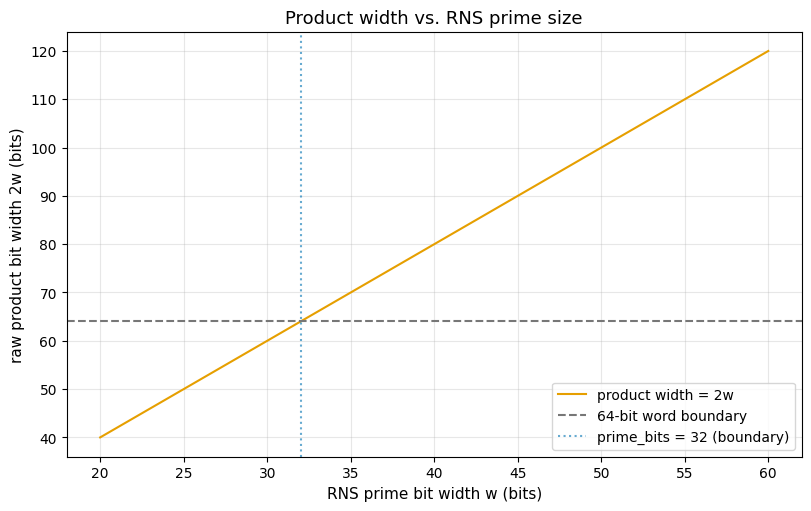

In [5]:
fig = visualization.plot_product_width_vs_prime_bits(range(20, 61))
plt.show()

## 3.3 Modular multiplication methods

Four conceptual implementations, all *correct* for their inputs. The point is to lay out their structural cost so the comparison table in §3.4 is concrete.

### Method 1 — Native-safe 31-bit modular multiply

For $q < 2^{31}$ and $a, b < q$, the product $ab < 2^{62}$ fits in an unsigned (or signed) 64-bit word. In C/C++ this compiles to one 64×64→64 product (low half) plus a modular reduction (Barrett or Montgomery in production code).

### Method 2 — 36-bit modular multiply via 128-bit intermediate

On x86-64 / AArch64 with `__uint128_t` (or the `umulh` intrinsic), one can compute the full 72-bit product as the high+low halves of a 64×64→128 multiply. Convenient in scalar C/C++, less portable in vector/GPU code.

### Method 3 — 36-bit via 32-bit chunks (the educational view)

The Notebook 2 §2.5 decomposition: four chunk products plus carry/recomposition. We re-use it here as a software-only reference.

In [6]:
rng = np.random.default_rng(seed=20260426)
q36 = (1 << 36) - 5
a = int(rng.integers(0, q36, dtype=np.uint64))
b = int(rng.integers(0, q36, dtype=np.uint64))

raw = limb_decompose.product_36_as_32_words(a, b)
print(f"a = {a}")
print(f"b = {b}")
print(f"a*b (chunked)  = {raw}  ({raw.bit_length()} bits)")
print(f"(a*b) mod q36  = {raw % q36}")
print(f"reference      = {(a * b) % q36}")
print(f"match          = {raw % q36 == (a * b) % q36}")

a = 40622410579
b = 23115661149
a*b (chunked)  = 939013877999716895271  (70 bits)
(a*b) mod q36  = 62267612690
reference      = 62267612690
match          = True


### Method 4 — Radix-4 Booth shift-add

Implemented in `rns_arithmetic.booth.booth_mul`. **This is a correctness reference, not a performant implementation.** Its purpose is to count operations: ~13.5 expected non-zero signed partial-product rows for random 36-bit multipliers, on top of multiword-add machinery (recall Notebook 1 §1.4 and Notebook 2 §2.6).

## 3.4 Main comparison table

Per single modular multiplication, summarized:

In [7]:
comparison = pd.DataFrame(
    [
        {
            "method": "31-bit RNS primes",
            "keeps_36b": False,
            "product_width_problem": "product fits in 64 bits",
            "approx_cost_model": "more RNS limbs, simpler per-limb mul",
            "commodity_practicality": "high",
        },
        {
            "method": "36-bit with __uint128_t",
            "keeps_36b": True,
            "product_width_problem": "handled by compiler",
            "approx_cost_model": "one 64x64->128 product + reduction",
            "commodity_practicality": "good in scalar C/C++; less so in vector/GPU",
        },
        {
            "method": "36-bit with 32-bit chunks",
            "keeps_36b": True,
            "product_width_problem": "explicit multiword product",
            "approx_cost_model": "4 chunk products + carries + reduction",
            "commodity_practicality": "educational; sometimes useful",
        },
        {
            "method": "36-bit with Booth shift-add",
            "keeps_36b": True,
            "product_width_problem": "explicit multiword accumulator",
            "approx_cost_model": "~13.5 signed rows for random 36-bit values",
            "commodity_practicality": "poor as software",
        },
        {
            "method": "INT8 chunking (preview)",
            "keeps_36b": True,
            "product_width_problem": "explicit recomposition",
            "approx_cost_model": "25 byte products + recomposition + reduction",
            "commodity_practicality": "only with massive tensor throughput (Notebook 4)",
        },
    ]
)
comparison

,method,keeps_36b,product_width_problem,approx_cost_model,commodity_practicality
0,31-bit RNS primes,False,product fits in 64 bits,"more RNS limbs, simpler per-limb mul",high
1,36-bit with __uint128_t,True,handled by compiler,one 64x64->128 product + reduction,good in scalar C/C++; less so in vector/GPU
2,36-bit with 32-bit chunks,True,explicit multiword product,4 chunk products + carries + reduction,educational; sometimes useful
3,36-bit with Booth shift-add,True,explicit multiword accumulator,~13.5 signed rows for random 36-bit values,poor as software
4,INT8 chunking (preview),True,explicit recomposition,25 byte products + recomposition + reduction,only with massive tensor throughput (Notebook 4)


## 3.5 Break-even model

**Takeaway — the headline result of the series:** the 31-bit strategy ties the 36-bit strategy when

$$
\frac{C_{36}}{C_{31}} \;=\; \frac{\lceil Q_\text{bits}/31\rceil}{\lceil Q_\text{bits}/36\rceil}
\quad\xrightarrow{Q_\text{bits}\,\text{large}}\quad \frac{36}{31} \;\approx\; 1.16.
$$

The 31-bit strategy **wins** as soon as the per-limb cost ratio exceeds this break-even. So if your 36-bit modular multiplication is more than about 16% slower than your 31-bit modular multiplication on commodity hardware, you should already prefer 31-bit primes — *before* even considering vectorization, code simplicity, or portability.

(This is a first-order model. It ignores NTT details, memory hierarchy, prime availability, rescaling behaviour, and cryptographic parameter choices. But as a baseline it is hard to beat.)

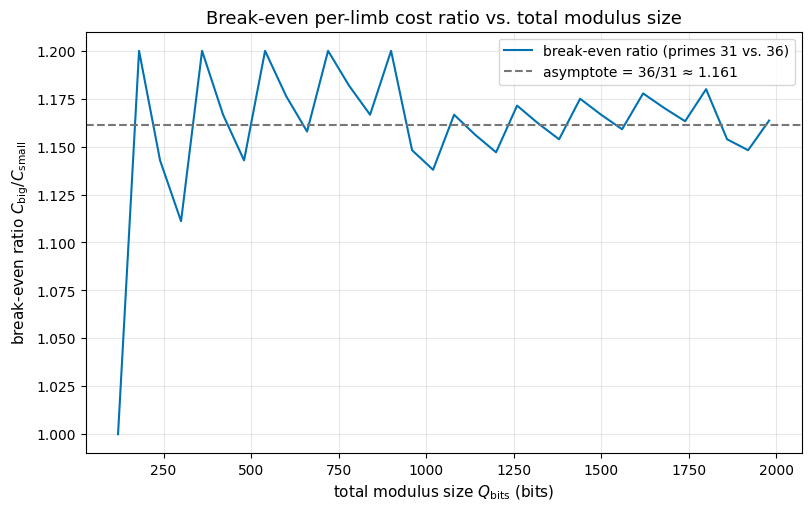

In [8]:
fig = visualization.plot_breakeven_curve(range(120, 2001, 60))
plt.show()

### Interactive: total cost vs. cost ratio

The widget below computes the total cost for both strategies given a per-limb cost ratio $C_{36}/C_{31}$. Whichever bar is shorter wins. The default state ($Q_\text{bits} = 720$, ratio = 1.5) is shown in the static cell first.

In [9]:
def show_breakeven(total_modulus_bits: int, cost_36_over_31: float) -> None:
    a = rns_cost_model.CostModel(total_modulus_bits, 31, cost_per_limb=1.0)
    b = rns_cost_model.CostModel(total_modulus_bits, 36, cost_per_limb=cost_36_over_31)
    breakeven = rns_cost_model.break_even_ratio(31, 36, total_modulus_bits)
    print(f"Q_bits             = {total_modulus_bits}")
    print(f"cost_36 / cost_31  = {cost_36_over_31:.3f}")
    print(f"31-bit limbs       = {a.limbs}     total cost = {a.total_cost:.2f}")
    print(f"36-bit limbs       = {b.limbs}     total cost = {b.total_cost:.2f}")
    print(f"break-even ratio   = {breakeven:.3f}  (asymptote {36 / 31:.3f})")
    winner = "31-bit" if a.total_cost < b.total_cost else "36-bit"
    print(f"winner             = {winner}")


show_breakeven(720, 1.5)

Q_bits             = 720
cost_36 / cost_31  = 1.500
31-bit limbs       = 24     total cost = 24.00
36-bit limbs       = 20     total cost = 30.00
break-even ratio   = 1.200  (asymptote 1.161)
winner             = 31-bit


In [10]:
interact(
    show_breakeven,
    total_modulus_bits=IntSlider(value=720, min=120, max=2000, step=60, description="Q_bits"),
    cost_36_over_31=FloatSlider(value=1.5, min=0.5, max=4.0, step=0.05, description="C_36/C_31"),
);

interactive(children=(IntSlider(value=720, description='Q_bits', max=2000, min=120, step=60), FloatSlider(valu…

## Takeaway

- **The break-even ratio between 31-bit and 36-bit RNS primes is ≈ 1.16** for large $Q_\text{bits}$. This is the headline number of the entire series.
- 31-bit primes need ~16% more limbs to reach the same total modulus, but their per-limb modular multiplication is dramatically simpler on commodity 64-bit CPUs because the 62-bit raw product fits a single word.
- 36-bit primes can be made to work via `__uint128_t`, 32-bit chunking, or Booth shift-add, but each path adds either non-portability, recomposition cost, or both.
- The right design question is **"can I choose RNS prime sizes so that the per-limb product fits the native arithmetic width?"** — not "can I Booth-recode a 36-bit multiplication?".
- Notebook 4 looks at the same question for **INT8 / Tensor Core** hardware, where the chunk count blows up to 25 per multiplication.